FILE OVERVIEW TABLE

In [2]:
import pandas as pd
import sys
sys.path.append('..')
from src.data_loader import *

files = {
    'aisles': load_aisles(),
    'departments': load_departments(),
    'products': load_products(),
    'orders': load_orders(),
    'order_products_train': load_order_products_train(),
}

summary = []
for name, df in files.items():
    summary.append({
        'file': name,
        'rows': f"{df.shape[0]:,}",
        'columns': df.shape[1],
        'fields': ', '.join(df.columns.tolist()),
        'nulls': df.isnull().sum().sum(),
    })

pd.DataFrame(summary)

,file,rows,columns,fields,nulls
0,aisles,134,2,"aisle_id, aisle",0
1,departments,21,2,"department_id, department",0
2,products,"49,688",4,"product_id, product_name, aisle_id, department_id",0
3,orders,"3,421,083",7,"order_id, user_id, eval_set, order_number, ord...",206209
4,order_products_train,"1,384,617",4,"order_id, product_id, add_to_cart_order, reord...",0


ORDER ANALYSIS

In [3]:
orders = load_orders()
print(f"Unique users:  {orders['user_id'].nunique():,}")
print(f"Total orders:  {orders['order_id'].nunique():,}")
print()
print("Eval set breakdown:")
print(orders['eval_set'].value_counts())
print()
print("Orders per user:")
print(orders.groupby('user_id')['order_id'].count().describe())

Unique users:  206,209
Total orders:  3,421,083

Eval set breakdown:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Orders per user:
count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64


Orders per user histogram

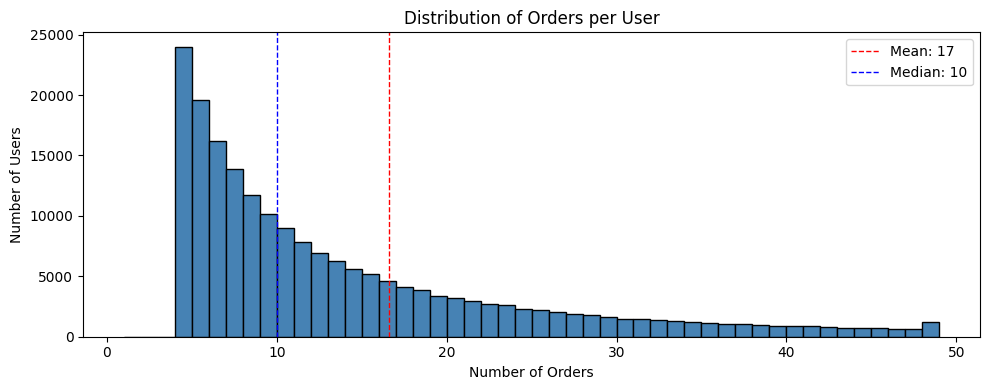

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

orders_per_user = orders.groupby('user_id')['order_id'].count()

plt.figure(figsize=(10, 4))
plt.hist(orders_per_user, bins=range(1, 50), edgecolor='black', color='steelblue')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Users')
plt.title('Distribution of Orders per User')
plt.axvline(orders_per_user.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {orders_per_user.mean():.0f}')
plt.axvline(orders_per_user.median(), color='blue', linestyle='dashed', linewidth=1, label=f'Median: {orders_per_user.median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/eda/orders_per_user.png', dpi=150)
plt.show()

 Reorder gap histogram

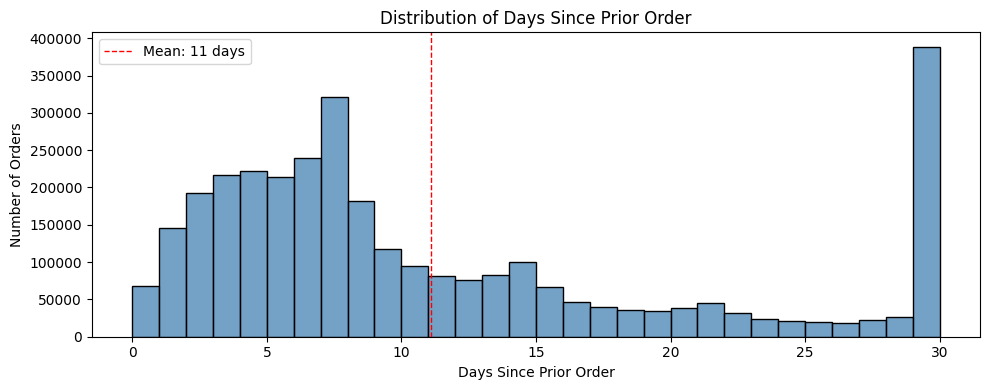

In [11]:
gap = orders['days_since_prior_order'].dropna()

plt.figure(figsize=(10, 4))
sns.histplot(gap, bins=range(0, 31), edgecolor='black', color='steelblue')
plt.xlabel('Days Since Prior Order')
plt.ylabel('Number of Orders')
plt.title('Distribution of Days Since Prior Order')
plt.axvline(gap.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {gap.mean():.0f} days')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/eda/days_since_prior_order.png', dpi=150)
plt.show()